In [22]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt


In [23]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [24]:
import pandas as pd

df = pd.read_csv("dataset_6/loan (1).csv")

df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [25]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [26]:
columnas_texto = df.select_dtypes(include="str").columns

for columna in columnas_texto:
    print("\n" + "=" * 50)
    print(columna)
    print("=" * 50)
    print(df[columna].value_counts())


ApplicationDate
ApplicationDate
2018-01-01    1
2018-01-02    1
2018-01-03    1
2018-01-04    1
2018-01-05    1
             ..
2072-09-29    1
2072-09-30    1
2072-10-01    1
2072-10-02    1
2072-10-03    1
Name: count, Length: 20000, dtype: int64

EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64

HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


In [27]:
# Crear una copia del dataset original
df_modelo = df.copy()

print("Dataset original:", df.shape)
print("Copia para el modelo:", df_modelo.shape)

Dataset original: (20000, 36)
Copia para el modelo: (20000, 36)


In [28]:
# Eliminar la variable que no utilizaremos
df_modelo = df_modelo.drop(columns=["ApplicationDate"])

In [29]:
print("Copia para el modelo:", df_modelo.shape)

Copia para el modelo: (20000, 35)


In [30]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
    
]

# Convertir variables categóricas a variables numéricas
df_modelo = pd.get_dummies(
    df_modelo,
    columns=columnas_categoricas,
    dtype=int
)

In [31]:
print("Copia para el modelo:", df_modelo.shape)

Copia para el modelo: (20000, 51)


In [32]:
X = df_modelo.drop("RiskScore", axis=1)
y = df_modelo["RiskScore"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (20000, 50)
Forma de y: (20000,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 50)
X_test: (4000, 50)
y_train: (16000,)
y_test: (4000,)


In [34]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [35]:
# Normalización utilizando nuestra función
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicamos los mismos parámetros a test
X_test_norm = (X_test - mu) / sigma

In [36]:
import torch

X_train_t = torch.tensor(X_train_norm.to_numpy(), dtype=torch.float32)
X_test_t = torch.tensor(X_test_norm.to_numpy(), dtype=torch.float32)

y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

In [56]:
D_in = X_train_t.shape[1]
H = 100
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    
    torch.nn.Linear(H, D_out)
).to("cuda")

In [57]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.04)

epochs = 10000
log_each = 100
l = []
model.train()
for e in range(1, epochs+1):

    # forward
    y_pred = model(X_train_t.cuda())

    # loss
    loss = criterion(
    y_pred,
    y_train_t.reshape(-1, 1).cuda()
)
    l.append(loss.item())

    # ponemos a cero los gradientes
    optimizer.zero_grad()

    # Backprop (calculamos todos los gradientes automáticamente)
    loss.backward()

    # update de los pesos
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")


Epoch 100/10000 Loss 548.69644
Epoch 200/10000 Loss 279.57410
Epoch 300/10000 Loss 188.06033
Epoch 400/10000 Loss 141.93194
Epoch 500/10000 Loss 114.12150
Epoch 600/10000 Loss 95.51635
Epoch 700/10000 Loss 82.19089
Epoch 800/10000 Loss 72.17474
Epoch 900/10000 Loss 64.36892
Epoch 1000/10000 Loss 58.11496
Epoch 1100/10000 Loss 52.99274
Epoch 1200/10000 Loss 48.72100
Epoch 1300/10000 Loss 45.10414
Epoch 1400/10000 Loss 42.00249
Epoch 1500/10000 Loss 39.31305
Epoch 1600/10000 Loss 36.95869
Epoch 1700/10000 Loss 34.88057
Epoch 1800/10000 Loss 33.03213
Epoch 1900/10000 Loss 31.37669
Epoch 2000/10000 Loss 29.88648
Epoch 2100/10000 Loss 28.53784
Epoch 2200/10000 Loss 27.31145
Epoch 2300/10000 Loss 26.19153
Epoch 2400/10000 Loss 25.16462
Epoch 2500/10000 Loss 24.21986
Epoch 2600/10000 Loss 23.34755
Epoch 2700/10000 Loss 22.53973
Epoch 2800/10000 Loss 21.78955
Epoch 2900/10000 Loss 21.09102
Epoch 3000/10000 Loss 20.43886
Epoch 3100/10000 Loss 19.82871
Epoch 3200/10000 Loss 19.25657
Epoch 3300/1

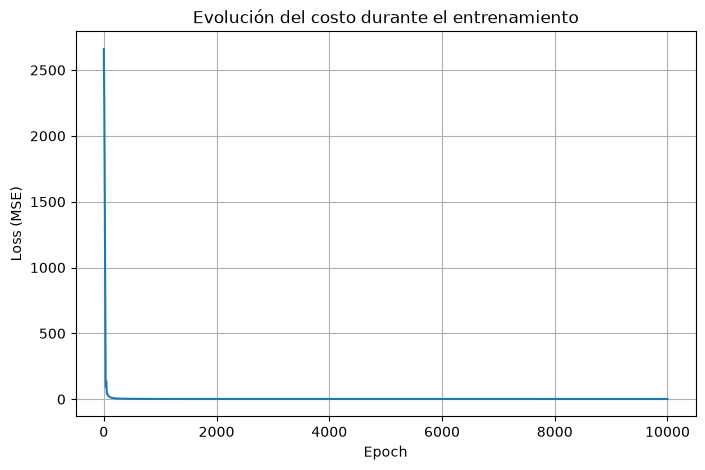

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(l)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Evolución del costo durante el entrenamiento")

plt.grid()
plt.show()

In [53]:
def evaluate(x):

    model.eval()

    y_pred = model(x)

    return y_pred

In [59]:
y_pred_test = evaluate(X_test_t.cuda())

In [60]:
for i in range(10):

    print(
        f"Real: {y_test_t[i].item():.2f} "
        f"| Predicción: {y_pred_test[i].item():.2f}"
    )
    

Real: 41.60 | Predicción: 41.95
Real: 38.40 | Predicción: 38.55
Real: 53.00 | Predicción: 51.70
Real: 50.00 | Predicción: 53.44
Real: 51.00 | Predicción: 51.04
Real: 47.00 | Predicción: 47.04
Real: 52.00 | Predicción: 52.16
Real: 46.00 | Predicción: 45.23
Real: 69.00 | Predicción: 68.47
Real: 55.00 | Predicción: 54.31
